#  Power System Load Type Prediction
## Machine Learning Classification






## Step 1: Import Libraries



In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

import warnings
warnings.filterwarnings('ignore')


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 2: Load the Dataset



In [48]:
df = pd.read_csv('load_data.csv')

print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (35041, 9)

Column Names: ['Date_Time', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'Load_Type']

First 5 rows:


,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type
0,01-01-2018 00:15,8.753692,2.95,0.0,0.0,73.210000,100.0,900.000000,Light_Load
1,01-01-2018 00:30,4.000000,4.46,0.0,0.0,66.770000,100.0,1800.000000,Light_Load
2,01-01-2018 00:45,3.240000,3.28,0.0,0.0,70.280000,100.0,8070.880991,Light_Load
3,01-01-2018 01:00,3.310000,3.56,0.0,0.0,68.090000,100.0,3600.000000,Light_Load
4,01-01-2018 01:15,3.820000,4.50,0.0,0.0,133.655666,NaN,4500.000000,Light_Load


In [49]:
print("Data Types:")
print(df.dtypes)
print("\nBasic Statistics:")
df.describe()

Data Types:
Date_Time                                object
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                     float64
Load_Type                                object
dtype: object

Basic Statistics:


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,33482.000000,34165.000000,33885.000000,34586.000000,34691.000000,33570.000000,34586.000000
mean,30.873061,14.704573,4.386097,0.012947,90.740871,94.926552,48013.664032
std,41.415015,20.342721,9.090181,0.019726,39.745395,49.826872,34046.492333
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.310000,2.340000,0.000000,0.000000,66.295000,99.800000,22500.000000
50%,5.290000,5.180000,0.000000,0.000000,90.080000,100.000000,45000.000000
75%,53.560000,23.510000,2.298558,0.020000,100.000000,100.000000,68400.000000
max,435.019069,262.630718,78.809000,0.188166,299.996814,299.969494,248821.810465


---
## Step 3: Exploratory Data Analysis (EDA)




In [50]:
print("Missing Values per Column:")
print(df.isnull().sum())
print("\nMissing % per Column:")
print(round(df.isnull().sum() / len(df) * 100, 2))

Missing Values per Column:
Date_Time                                  0
Usage_kWh                               1559
Lagging_Current_Reactive.Power_kVarh     876
Leading_Current_Reactive_Power_kVarh    1156
CO2(tCO2)                                455
Lagging_Current_Power_Factor             350
Leading_Current_Power_Factor            1471
NSM                                      455
Load_Type                                  0
dtype: int64

Missing % per Column:
Date_Time                               0.00
Usage_kWh                               4.45
Lagging_Current_Reactive.Power_kVarh    2.50
Leading_Current_Reactive_Power_kVarh    3.30
CO2(tCO2)                               1.30
Lagging_Current_Power_Factor            1.00
Leading_Current_Power_Factor            4.20
NSM                                     1.30
Load_Type                               0.00
dtype: float64


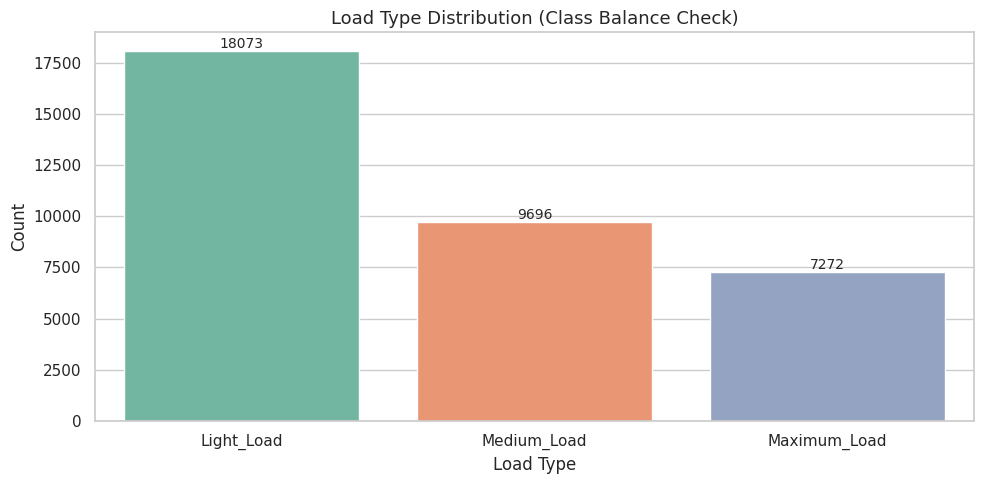

Load_Type
Light_Load      18073
Medium_Load      9696
Maximum_Load     7272
Name: count, dtype: int64

Class %:
Load_Type
Light_Load      51.6
Medium_Load     27.7
Maximum_Load    20.8
Name: proportion, dtype: float64


In [51]:
order = df['Load_Type'].value_counts().index
sns.countplot(data=df, x='Load_Type', order=order, palette='Set2')
plt.title('Load Type Distribution (Class Balance Check)', fontsize=13)
plt.xlabel('Load Type')
plt.ylabel('Count')
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2, p.get_height()),
                       ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print(df['Load_Type'].value_counts())
print("\nClass %:")
print(round(df['Load_Type'].value_counts(normalize=True) * 100, 1))

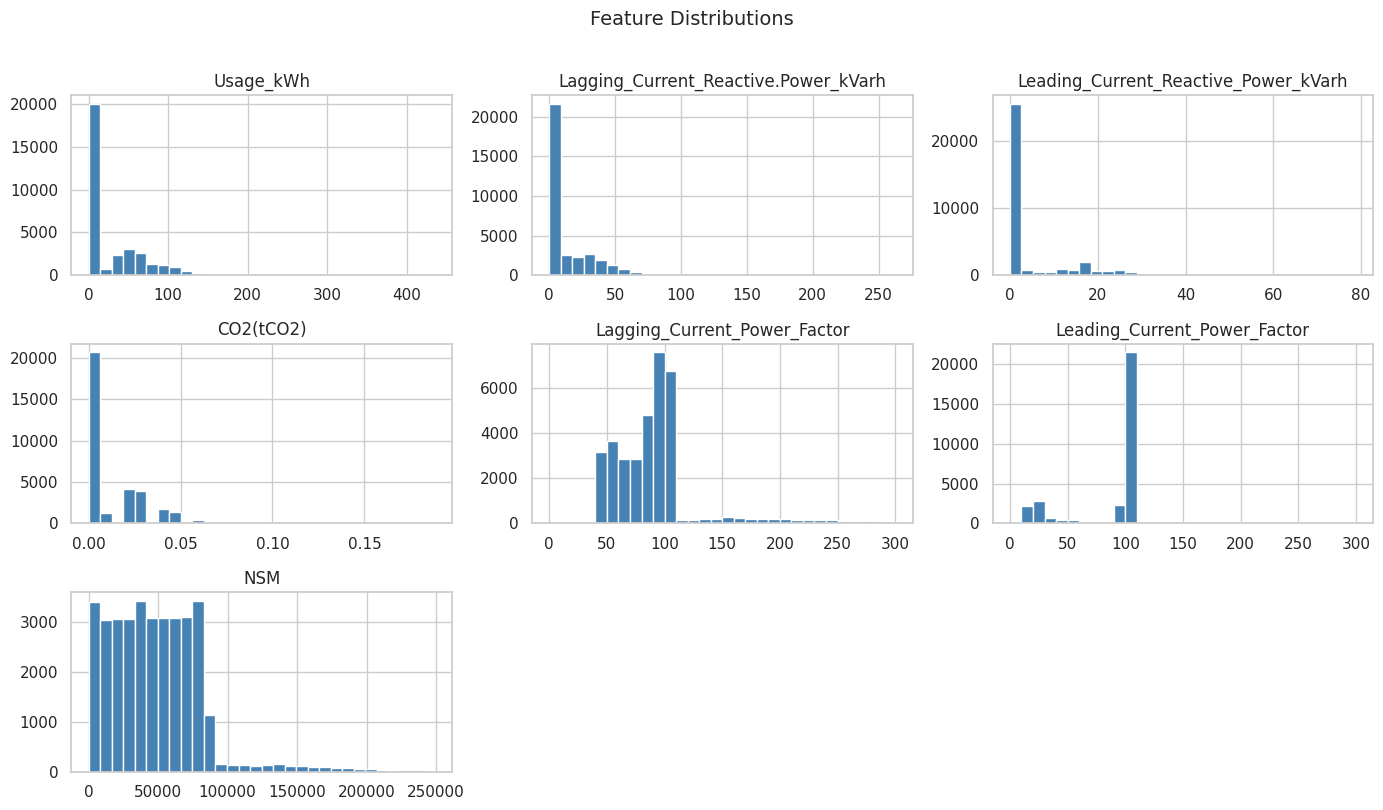

In [52]:
num_cols = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
            'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
            'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM']

df[num_cols].hist(bins=30, figsize=(14, 8), color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

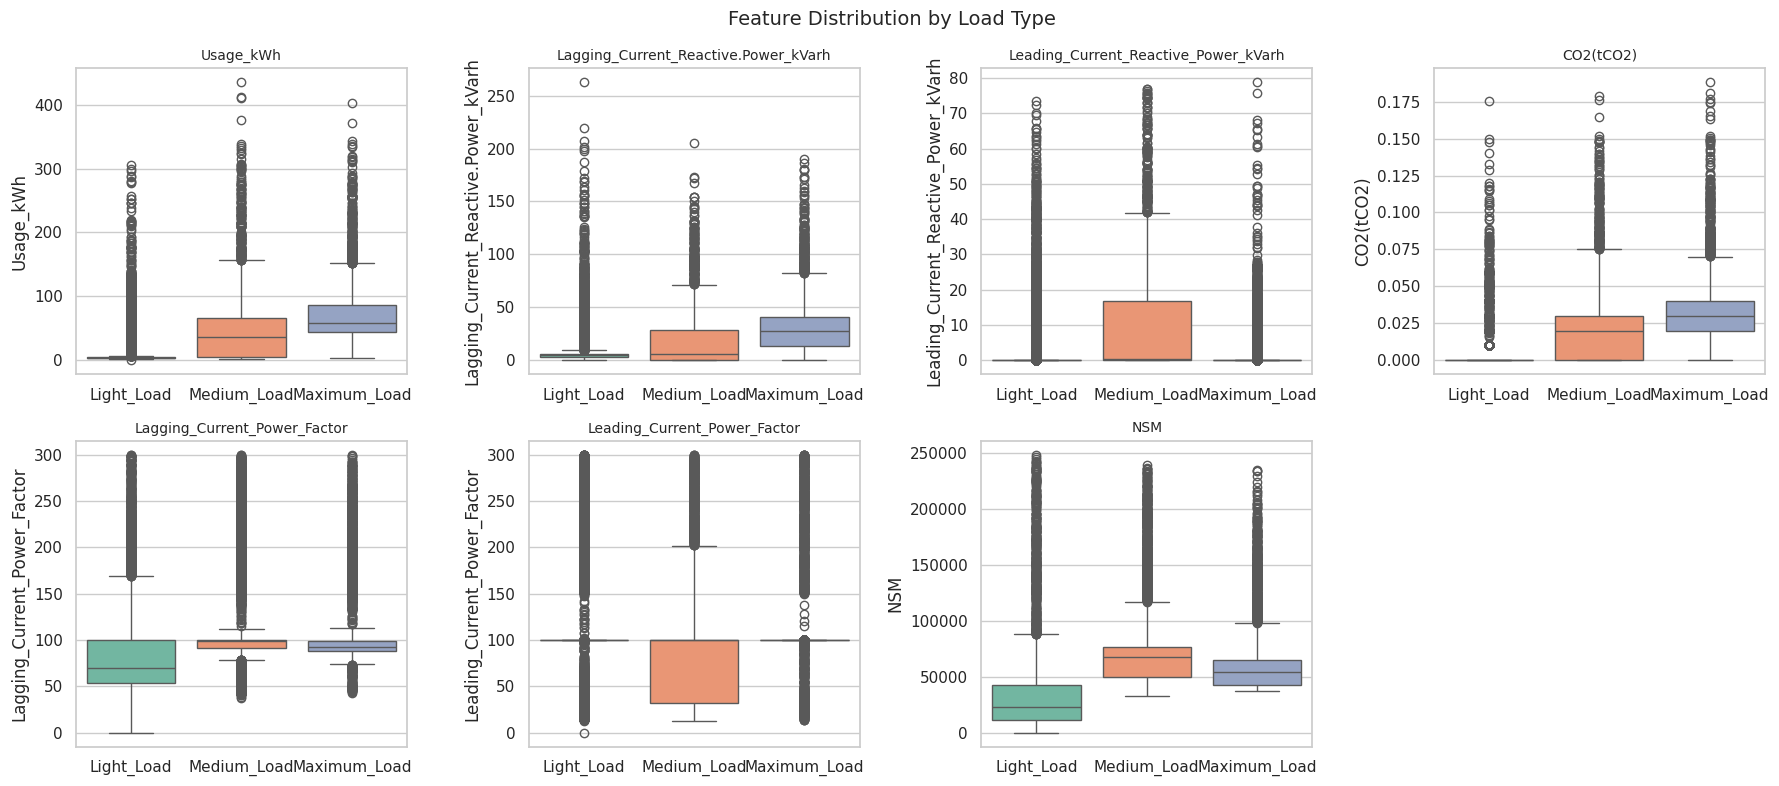

In [53]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Load_Type', y=col, palette='Set2', ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

# Hide the last unused subplot
axes[-1].set_visible(False)

plt.suptitle('Feature Distribution by Load Type', fontsize=14)
plt.tight_layout()
plt.show()

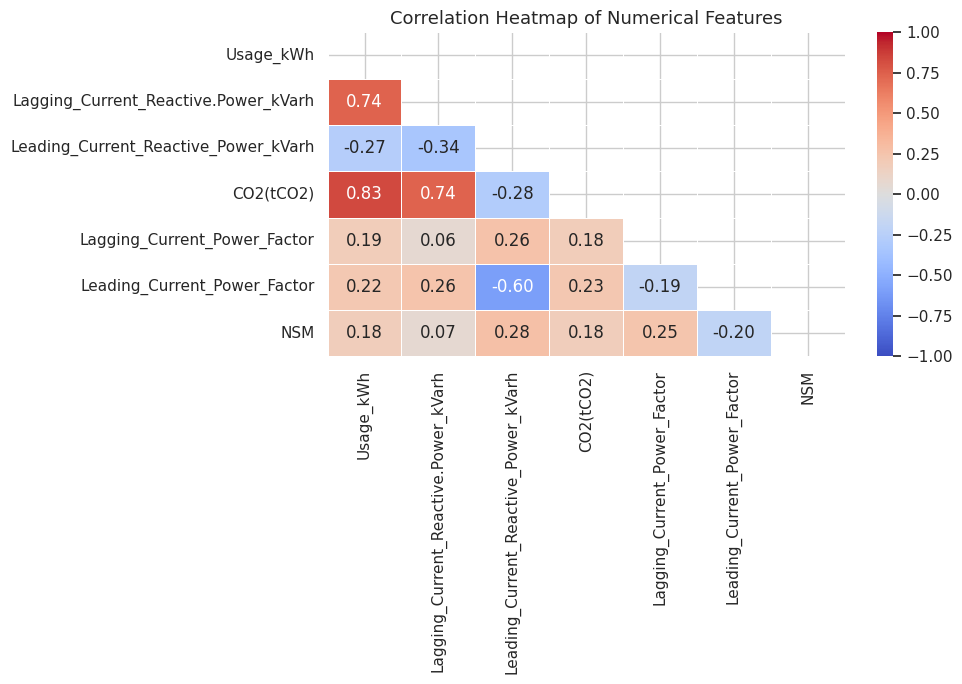

In [54]:
plt.figure(figsize=(10, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 4: Feature Engineering



In [55]:
df['Date_Time'] = pd.to_datetime(df['Date_Time'], dayfirst=True)


df['hour']        = df['Date_Time'].dt.hour
df['day_of_week'] = df['Date_Time'].dt.dayofweek
df['month']       = df['Date_Time'].dt.month

print("New features created: hour, day_of_week, month")
print(df[['Date_Time', 'hour', 'day_of_week', 'month']].head(8))

New features created: hour, day_of_week, month
            Date_Time  hour  day_of_week  month
0 2018-01-01 00:15:00     0            0      1
1 2018-01-01 00:30:00     0            0      1
2 2018-01-01 00:45:00     0            0      1
3 2018-01-01 01:00:00     1            0      1
4 2018-01-01 01:15:00     1            0      1
5 2018-01-01 01:30:00     1            0      1
6 2018-01-01 01:45:00     1            0      1
7 2018-01-01 02:00:00     2            0      1


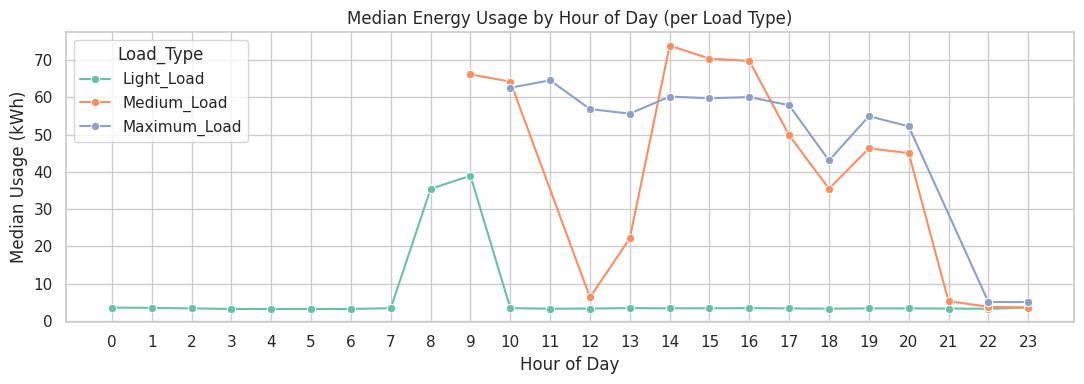

In [56]:
hourly_usage = df.groupby(['hour', 'Load_Type'])['Usage_kWh'].median().reset_index()

plt.figure(figsize=(11, 4))
sns.lineplot(data=hourly_usage, x='hour', y='Usage_kWh',
             hue='Load_Type', palette='Set2', marker='o')
plt.title('Median Energy Usage by Hour of Day (per Load Type)')
plt.xlabel('Hour of Day')
plt.ylabel('Median Usage (kWh)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

---
## Step 5: Preprocessing

In [57]:
le = LabelEncoder()
df['Load_Type_enc'] = le.fit_transform(df['Load_Type'])

print("Label Encoding Mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

print("\nEncoded target sample:")
print(df[['Load_Type', 'Load_Type_enc']].head(6))

Label Encoding Mapping:
  Light_Load → 0
  Maximum_Load → 1
  Medium_Load → 2

Encoded target sample:
    Load_Type  Load_Type_enc
0  Light_Load              0
1  Light_Load              0
2  Light_Load              0
3  Light_Load              0
4  Light_Load              0
5  Light_Load              0


---
## Step 6: Train / Test Split (Time-Based)



In [58]:
features = ['Usage_kWh',
            'Lagging_Current_Reactive.Power_kVarh',
            'Leading_Current_Reactive_Power_kVarh',
            'CO2(tCO2)',
            'Lagging_Current_Power_Factor',
            'Leading_Current_Power_Factor',
            'NSM',
            'hour',
            'day_of_week',
            'month']


train = df[df['month'] != 12].copy()
test  = df[df['month'] == 12].copy()

X_train = train[features]
y_train = train['Load_Type_enc']
X_test  = test[features]
y_test  = test['Load_Type_enc']

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size:     {X_test.shape[0]} rows")
print(f"Features used:     {len(features)}")

Training set size: 32064 rows
Test set size:     2977 rows
Features used:     10


---
## Step 7: Handle Missing Values (Imputation)



In [59]:
imputer = SimpleImputer(strategy='median')

X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)


print("NaN in X_train after imputation:", np.isnan(X_train_imp).sum())
print("NaN in X_test  after imputation:", np.isnan(X_test_imp).sum())

NaN in X_train after imputation: 0
NaN in X_test  after imputation: 0


---
## Step 7: Handle Missing Values (Imputation)



In [60]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

print("Scaling complete.")
print(f"X_train_sc shape: {X_train_sc.shape}")
print(f"X_test_sc  shape: {X_test_sc.shape}")

Scaling complete.
X_train_sc shape: (32064, 10)
X_test_sc  shape: (2977, 10)


---
## Step 8: Feature Scaling



In [61]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sc, y_train)

y_pred_lr = lr_model.predict(X_test_sc)
print("Logistic Regression trained!")
print(f"   Accuracy on Test Set: {round(accuracy_score(y_test, y_pred_lr)*100, 2)}%")

Logistic Regression trained!
   Accuracy on Test Set: 62.08%


In [62]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_imp, y_train)

y_pred_rf = rf_model.predict(X_test_imp)
print("Random Forest trained!")
print(f"   Accuracy on Test Set: {round(accuracy_score(y_test, y_pred_rf)*100, 2)}%")

Random Forest trained!
   Accuracy on Test Set: 93.18%


In [63]:
try:
    from xgboost import XGBClassifier

    xgb_model = XGBClassifier(n_estimators=100, random_state=42,
                               eval_metric='mlogloss', verbosity=0)
    xgb_model.fit(X_train_imp, y_train)

    y_pred_xgb = xgb_model.predict(X_test_imp)
    print("XGBoost trained!")
    print(f"   Accuracy on Test Set: {round(accuracy_score(y_test, y_pred_xgb)*100, 2)}%")
    xgb_available = True

except ImportError:
    print("XGBoost not installed. Run: pip install xgboost")
    print("   Continuing with Logistic Regression and Random Forest.")
    xgb_available = False

XGBoost trained!
   Accuracy on Test Set: 93.48%


---
## Step 10: Model Evaluation



In [64]:
def get_metrics(y_true, y_pred, name):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred, average='weighted') * 100, 2),
        'Recall':    round(recall_score(y_true, y_pred, average='weighted') * 100, 2),
        'F1-Score':  round(f1_score(y_true, y_pred, average='weighted') * 100, 2),
    }

results = [
    get_metrics(y_test, y_pred_lr, 'Logistic Regression'),
    get_metrics(y_test, y_pred_rf, 'Random Forest'),
]

if xgb_available:
    results.append(get_metrics(y_test, y_pred_xgb, 'XGBoost'))

results_df = pd.DataFrame(results).set_index('Model')
print("\n📊 Model Comparison:")
print(results_df.to_string())


📊 Model Comparison:
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression     62.08      69.48   62.08     64.54
Random Forest           93.18      93.76   93.18     93.27
XGBoost                 93.48      94.05   93.48     93.54


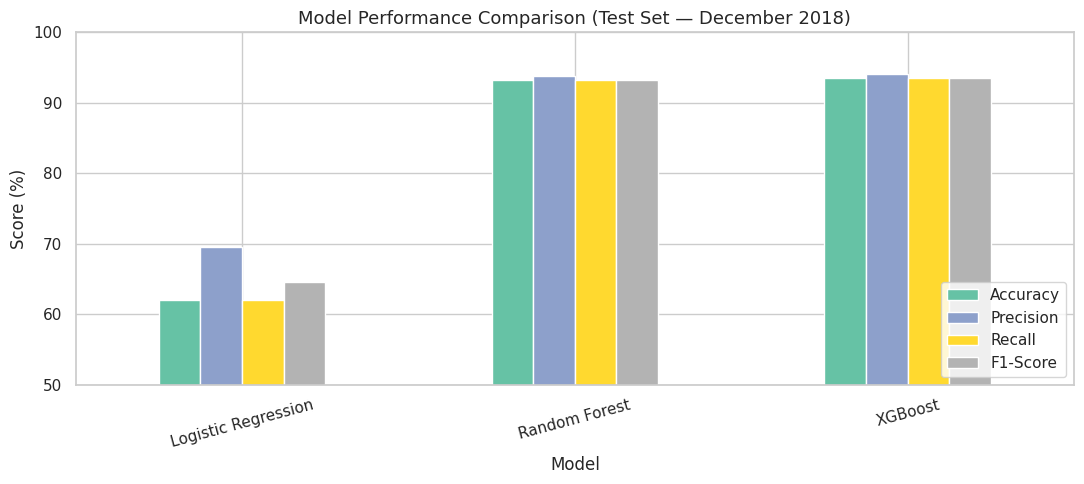

In [65]:
results_df.plot(kind='bar', figsize=(11, 5), colormap='Set2', edgecolor='white')
plt.title('Model Performance Comparison (Test Set — December 2018)', fontsize=13)
plt.ylabel('Score (%)')
plt.xticks(rotation=15)
plt.ylim(50, 100)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [66]:
print("=" * 55)
print("  Detailed Report — Random Forest (Best Model)")
print("=" * 55)
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

  Detailed Report — Random Forest (Best Model)
              precision    recall  f1-score   support

  Light_Load       0.99      0.92      0.95      1745
Maximum_Load       0.90      0.91      0.91       528
 Medium_Load       0.84      0.98      0.91       704

    accuracy                           0.93      2977
   macro avg       0.91      0.94      0.92      2977
weighted avg       0.94      0.93      0.93      2977



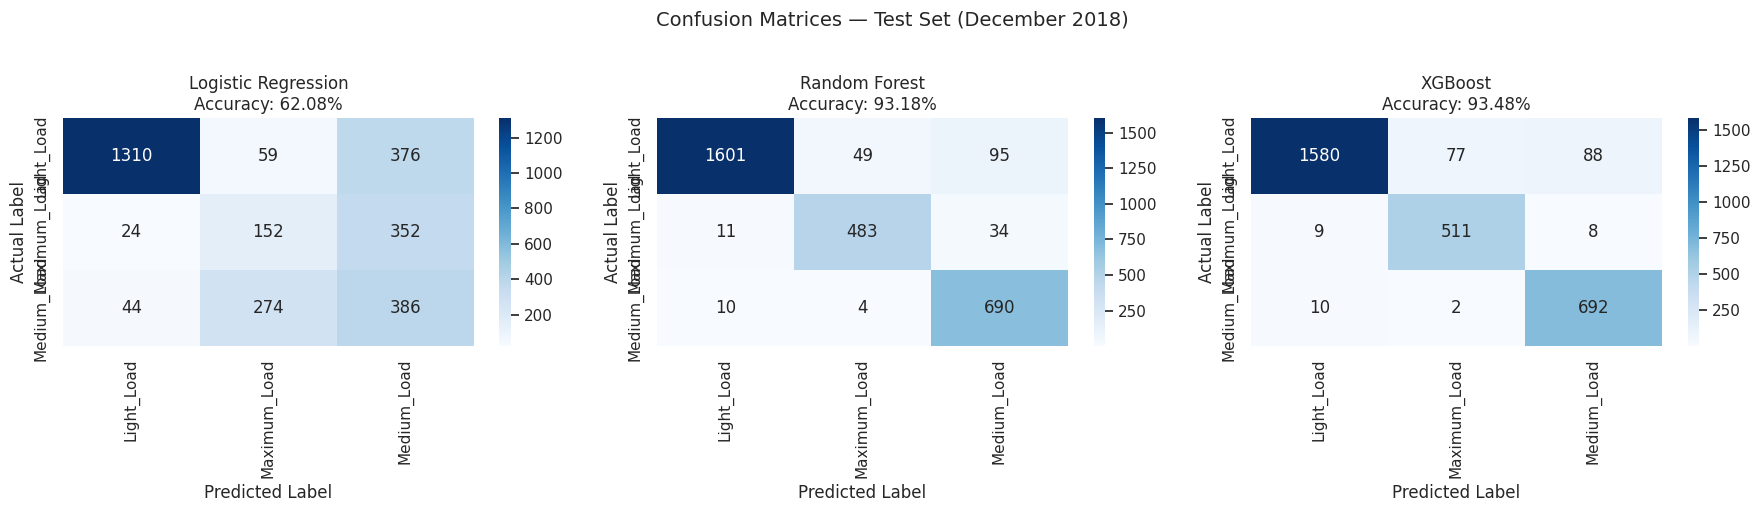

In [67]:
models_to_plot = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',       y_pred_rf),
]
if xgb_available:
    models_to_plot.append(('XGBoost', y_pred_xgb))

fig, axes = plt.subplots(1, len(models_to_plot), figsize=(6 * len(models_to_plot), 5))
if len(models_to_plot) == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, models_to_plot):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(f'{name}\nAccuracy: {round(accuracy_score(y_test,y_pred)*100,2)}%')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('Actual Label')

plt.suptitle('Confusion Matrices — Test Set (December 2018)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 11: Feature Importance Analysis



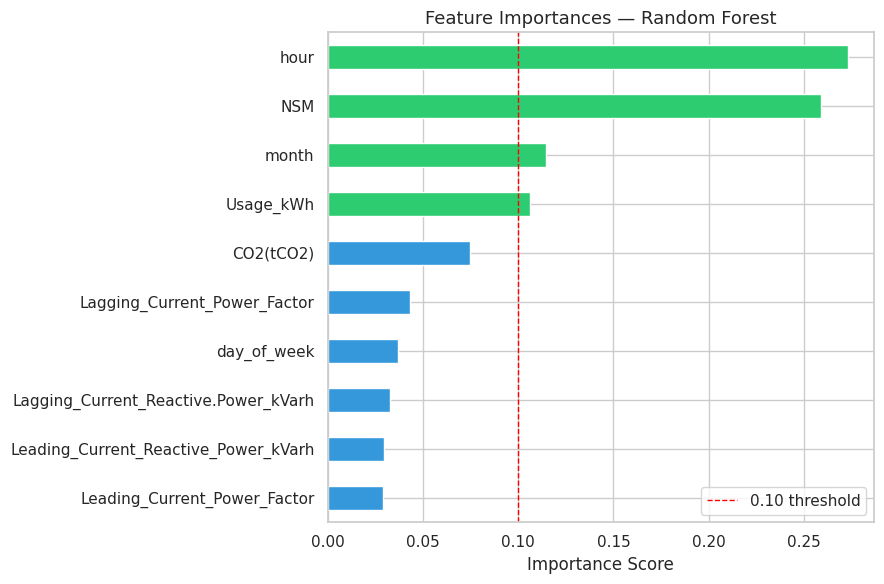


Feature Importances (sorted):
hour                                    0.2730
NSM                                     0.2590
month                                   0.1147
Usage_kWh                               0.1060
CO2(tCO2)                               0.0749
Lagging_Current_Power_Factor            0.0433
day_of_week                             0.0371
Lagging_Current_Reactive.Power_kVarh    0.0328
Leading_Current_Reactive_Power_kVarh    0.0298
Leading_Current_Power_Factor            0.0293
dtype: object


In [68]:
importances = pd.Series(rf_model.feature_importances_, index=features)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = ['#2ecc71' if v > 0.1 else '#3498db' for v in importances.values]
importances.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Feature Importances — Random Forest', fontsize=13)
plt.xlabel('Importance Score')
plt.axvline(x=0.1, color='red', linestyle='--', linewidth=1, label='0.10 threshold')
plt.legend()
plt.tight_layout()
plt.show()

print("\nFeature Importances (sorted):")
print(importances.sort_values(ascending=False).apply(lambda x: f"{x:.4f}"))

---
## Step 12: Summary & Conclusions



In [69]:
print(" Notebook complete!")
print(f"\nBest Model: Random Forest")
print(f"Test Accuracy: {round(accuracy_score(y_test, y_pred_rf)*100, 2)}%")
print(f"Test F1-Score (weighted): {round(f1_score(y_test, y_pred_rf, average='weighted')*100, 2)}%")

 Notebook complete!

Best Model: Random Forest
Test Accuracy: 93.18%
Test F1-Score (weighted): 93.27%
